In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use("../fopraplot.mplstyle")

### 1. CW ODMR

In [ ]:
odmr = np.genfromtxt("./data/cwODMR/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag1 = np.genfromtxt("./data/cwODMR_magnet_1/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag2 = np.genfromtxt("./data/cwODMR_magnet_2/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag3 = np.genfromtxt("./data/cwODMR_magnet_3/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))
odmr_mag4 = np.genfromtxt("./data/cwODMR_magnet_4/cwODMR.csv", skip_header=1, delimiter=";", usecols=(1,3))

# convert frequencies to GHz and currents to mA
odmr[:,0] *= 1e-9
odmr[:,1] = 1e3*odmr[:,1]
odmr_mag1[:,0] *= 1e-9
odmr_mag1[:,1] = 1e3*odmr_mag1[:,1]
odmr_mag2[:,0] *= 1e-9
odmr_mag2[:,1] = 1e3*odmr_mag2[:,1]
odmr_mag3[:,0] *= 1e-9
odmr_mag3[:,1] = 1e3*odmr_mag3[:,1]
odmr_mag4[:,0] *= 1e-9
odmr_mag4[:,1] = 1e3*odmr_mag4[:,1]

array([1.00016971, 0.0138373 , 0.00511768, 2.86946838])

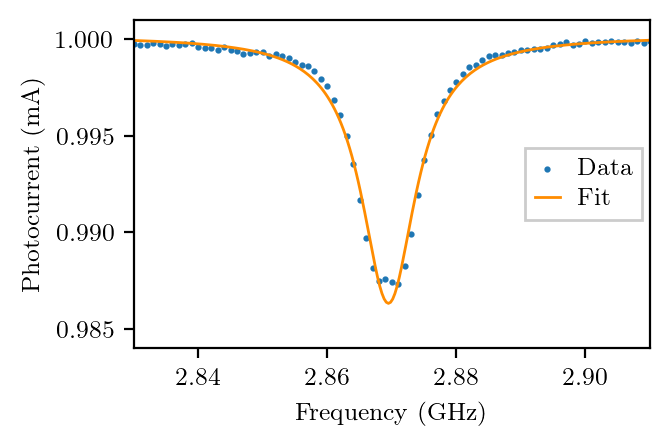

In [273]:
def gauss(x, A, B, s, x0):
    return A * (1 - B * np.exp(-(x-x0)**2 / (2*s**2)))

def lorentzian(x, A, B, w, x0):
    return A * (1 - B / (1 + (x-x0)**2 / w**2))

params, pcov = curve_fit(lorentzian, odmr[:,0], odmr[:,1]+1, p0=(1, 0.013, 0.01, 2.87))

xs = np.linspace(2.83, 2.93, 300)

fig1a, ax = plt.subplots()
ax.scatter(odmr[:,0], odmr[:,1]+1, marker=".", label="Data")
ax.plot(xs, lorentzian(xs, *params), c="darkorange", label="Fit")
ax.set(xlabel="Frequency (GHz)", ylabel="Photocurrent (mA)", xlim=(2.83, 2.91), ylim=(0.984, 1.001))
ax.legend(loc="right")

# fig1a.savefig("./figs/zero_field_odmr.pdf")
params

In [272]:
contrast = params[1] / params[0]
contrast_err = pcov[1,1]**0.5 / params [0] + pcov[0,0]**0.5 * params[1] / params[0]**2
print(f"Contrast = ({contrast*100:.2f} +- {contrast_err*100:.2f}) %")
print(f"Resonance frequency = ({params[3]:.4f} +- {pcov[3,3]**0.5:.4f}) GHz")

Contrast = (1.38 +- 0.02) %
Resonance frequency = (2.8695 +- 0.0001) GHz


array([4.99989107e-01, 1.72037831e-02, 3.66237591e-03, 2.86945565e+00,
       2.23389368e-03])

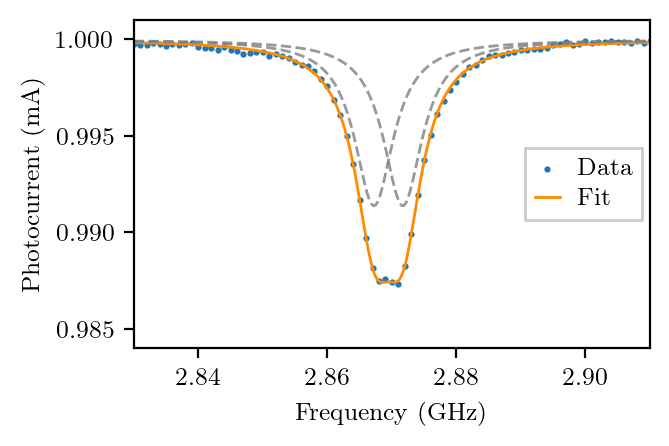

In [ ]:
def double_lorentzian(x, A, B, w, x0, d):
    return lorentzian(x+d, A, B, w, x0) + lorentzian(x-d, A, B, w, x0)

params, pcov = curve_fit(double_lorentzian, odmr[:,0], odmr[:,1]+1, p0=(0.5, 0.019, 0.0033, 2.8696, 0.0024))

fig1b, ax = plt.subplots()
ax.scatter(odmr[:,0], odmr[:,1]+1, marker=".", label="Data")
ax.plot(xs, double_lorentzian(xs, *params), c="darkorange", label="Fit")
ax.plot(xs, lorentzian(xs+params[-1], *params[:-1])+params[0], c="gray", linestyle="--", alpha=.8)
ax.plot(xs, lorentzian(xs-params[-1], *params[:-1])+params[0], c="gray", linestyle="--", alpha=.8)
ax.set(xlabel="Frequency (GHz)", ylabel="Photocurrent (mA)", xlim=(2.83, 2.91), ylim=(0.984, 1.001))
ax.legend(loc="right")

# fig1b.savefig("./figs/zero_field_odmr_double_lorentzian.pdf")
params

In [6]:
print(f"Mid Resonance Frequency: \t ({params[3]:.5f} +- {pcov[3,3]**0.5:.5f}) GHz")
print(f"Zero Field m=+-1 Splitting: \t ({params[-1]*1e3:.2f} +- {pcov[-1,-1]**0.5*1e3:.2f}) MHz")

Mid Resonance Frequency: 	 (2.86946 +- 0.00002) GHz
Zero Field m=+-1 Splitting: 	 (2.23 +- 0.02) MHz


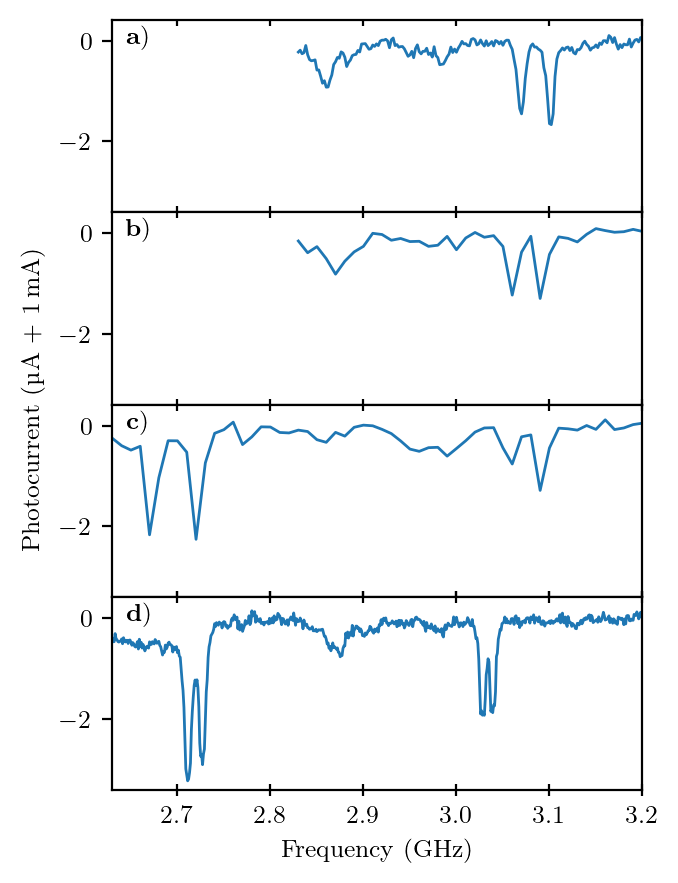

In [ ]:
plt.rcParams["figure.autolayout"] = False

fig2, axs = plt.subplots(ncols=1, nrows=4, sharex=True, sharey=True, figsize=(3.42, 5))
fig2.subplots_adjust(hspace=0)

odmr_list = [odmr_mag1, odmr_mag2, odmr_mag3, odmr_mag4]
subplot_labels = ["a)", "b)", "c)", "d)"]
for i, data in enumerate(odmr_list):
    axs[i].plot(data[:,0], data[:,1]*1e3)
    axs[i].tick_params(axis="x", which="both", direction="in", top=True, bottom=True, length=2)
    axs[i].text(2.645, -0.05, r"\textbf "+subplot_labels[i])

axs[3].tick_params(axis="x", which="both", direction="inout", top=True, bottom=True, length=4)
axs[3].set(xlabel="Frequency (GHz)", xlim=(2.63, 3.2))
fig2.supylabel(r"Photocurrent (\unit{\micro\A} + \qty{1}{\mA})", fontsize=9, x=-0.01)

# fig2.savefig("./figs/cwodmr_magnets.pdf", bbox_inches="tight")
plt.rcParams["figure.autolayout"] = True

**Note:**

Strongest resonance peak in d) at $2.7115\, \mathrm{GHz}$, second peak at $2.7268\,\mathrm{GHz}$.

Frequency used for measurements $2.7160\,\mathrm{GHz}$.


### 2. Rabi Sequence

[0.27779744234803977,
 0.2643498995906582,
 0.37041958931242763,
 0.21621764385458228]

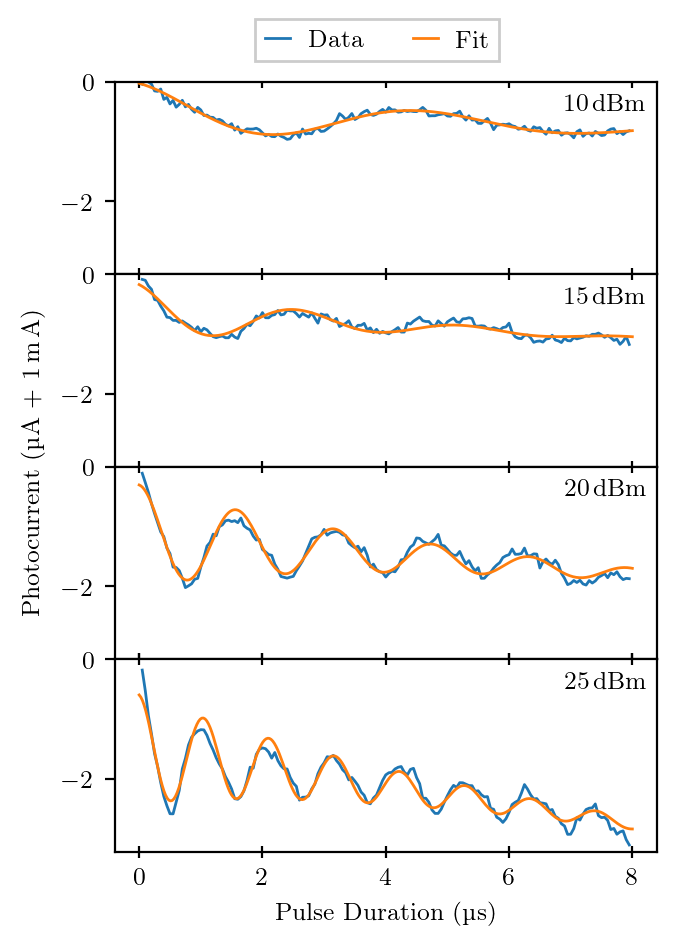

In [ ]:
rabi_0dbm = np.genfromtxt("./data/Rabi_0dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))
rabi_5dbm = np.genfromtxt("./data/Rabi_-5dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))
rabi_10dbm = np.genfromtxt("./data/Rabi_-10dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))
rabi_15dbm = np.genfromtxt("./data/Rabi_-15dbm/Rabi.csv", skip_header=1, delimiter=";", usecols=(1,3))

# convert to mu s and muA
rabi_0dbm[:,0] *= 1e-3
rabi_0dbm[:,1] *= 1e6
rabi_5dbm[:,0] *= 1e-3
rabi_5dbm[:,1] *= 1e6
rabi_10dbm[:,0] *= 1e-3
rabi_10dbm[:,1] *= 1e6
rabi_15dbm[:,0] *= 1e-3
rabi_15dbm[:,1] *= 1e6


def damped_cos(t, A, B, gamma, omega, phi, C):
    return A * np.exp(-gamma*t) * np.cos(omega*t + phi) + B - C*t

rabi_list = [rabi_0dbm, rabi_5dbm, rabi_10dbm, rabi_15dbm]
params_list = []
rabi_freqs = []
pcov_list = []
rabi_freqs_err = []
gammas = []

for data in rabi_list:
    params, pcov = curve_fit(damped_cos, data[:,0], data[:,1], p0=(1, -1, 0.3, 3, 0, 0.2))
    params_list += [params]
    pcov_list += [pcov]
    rabi_freqs += [params[3]]
    rabi_freqs_err += [pcov[3,3]**0.5]
    gammas += [params[2]]

rabi_freqs = np.array(rabi_freqs) / (2*np.pi) # in MHz
rabi_freqs_err = np.array(rabi_freqs_err)
mw_powers_dbm = np.array([0, -5, -10, -15]) + 25
ts = np.linspace(0, 8, 300)


## plot
plt.rcParams["figure.autolayout"] = False

fig3, axs = plt.subplots(ncols=1, nrows=4, sharex=True, sharey=True, figsize=(3.5, 5))
fig3.subplots_adjust(hspace=0)

for i, data in enumerate(rabi_list):
    axs[3-i].plot(data[:,0], data[:,1], label="Data")
    axs[3-i].plot(ts, damped_cos(ts, *params_list[i]), label="Fit")
    axs[3-i].text(6.9, -0.5, r"$\qty{"+f"{mw_powers_dbm[i]}"+r"}{dBm}$")
    axs[i].tick_params(axis="x", which="both", direction="in", top=True, bottom=True, length=2)

axs[3].set(xlabel=r"Pulse Duration (\unit{\micro\s})", ylim=(-3.22, 0))
axs[3].tick_params(axis="x", which="both", direction="inout", top=True, bottom=True, length=4)

fig3.supylabel(r"Photocurrent (\unit{\micro\A} + \qty{1}{\m\A})", fontsize=9, x=-0.01)
h, l = axs[0].get_legend_handles_labels()
fig3.legend(h, l, loc="upper center", ncols=2, bbox_to_anchor=(0.5, 0.95))

# fig3.savefig("./figs/rabi.pdf", bbox_inches="tight")
plt.rcParams["figure.autolayout"] = True
gammas

array([0.05626964])

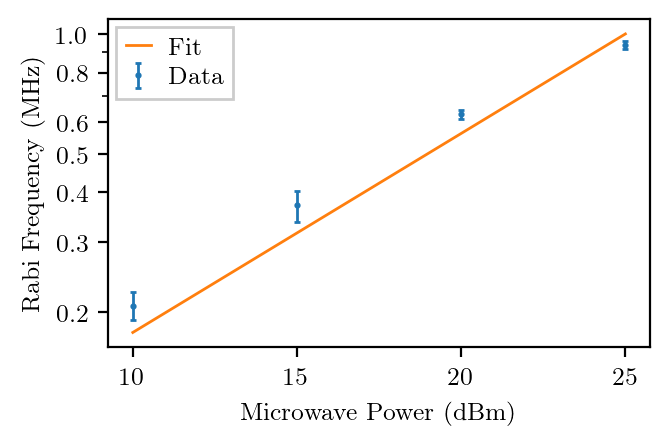

In [262]:
mw_powers = np.array([0, -5, -10, -15]) + 25 # in dBm

def fit(x, A):
    x = 10**(0.1*mw_powers)
    return A* x**0.5

params, pcov = curve_fit(fit, mw_powers, rabi_freqs)

fig4a, ax = plt.subplots()
ax.errorbar(mw_powers, rabi_freqs, yerr=rabi_freqs_err, marker=".", linestyle="", capsize=1, label="Data")
ax.plot(mw_powers, fit(mw_powers, *params), label="Fit")
ax.set(xlabel="Microwave Power (dBm)", ylabel="Rabi Frequency (MHz)", xscale="linear", 
       yscale="log", yticks=[0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0], 
       yticklabels=["0.2", "0.3", "0.4", "0.5", "0.6", "0.8", "1.0"],
       xticks=np.arange(10, 30, 5))
ax.legend()
# ax.grid(which="both")

# fig4a.savefig("./figs/rabi_power_logscale.pdf")
params

array([0.05626964])

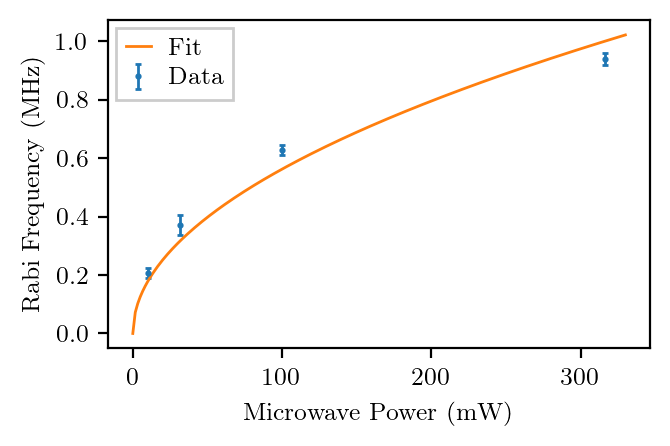

In [260]:
mw_powers = np.array([0, -5, -10, -15]) + 25 # in dBm
mw_powers = 10**(0.1*mw_powers) # in mW

def rabi_fit(x, A):
    return A * x**0.5

params, pcov = curve_fit(rabi_fit, mw_powers, rabi_freqs)

fig4b, ax = plt.subplots()
ax.errorbar(mw_powers, rabi_freqs, yerr=rabi_freqs_err, marker=".", linestyle="", capsize=1, label="Data")
ax.plot(np.linspace(0, 330, 200), rabi_fit(np.linspace(0, 330, 200), *params), label="Fit")
ax.set(xlabel="Microwave Power (mW)", ylabel="Rabi Frequency (MHz)", )
ax.legend()

# fig4b.savefig("./figs/rabi_power_linscale.pdf")
params

In [11]:
print(f"Rabi frequency at 0+25dBm: \t ({rabi_freqs[0]:.3f} +- {rabi_freqs_err[0]:.3f}) MHz")
print(f"pi-pulse at 0+25dBm: \t\t ({0.5/rabi_freqs[0]*1e3:.0f} +- {0.5*rabi_freqs_err[0]/rabi_freqs[0]**2*1e3:.0f}) ns")

Rabi frequency at 0+25dBm: 	 (0.941 +- 0.021) MHz
pi-pulse at 0+25dBm: 		 (532 +- 12) ns


### 3. Hahn Echo

In [255]:
import matplotlib as mpl

echo_500 = np.genfromtxt("./data/Hahnecho_500/Hahnecho.csv", skip_header=1, delimiter=";", usecols=(1,3))
echo_1000 = np.genfromtxt("./data/Hahnecho_1000/Hahnecho.csv", skip_header=1, delimiter=";", usecols=(1,3))
echo_1500 = np.genfromtxt("./data/Hahnecho_1500/Hahnecho.csv", skip_header=1, delimiter=";", usecols=(1,3))
echo_2000 = np.genfromtxt("./data/Hahnecho_good_2000/Hahnecho.csv", skip_header=1, delimiter=";", usecols=(1,3))
decay = np.genfromtxt("./data/Hahndecay_good/Hahndecay.csv", skip_header=1, delimiter=";", usecols=(1,3))

echo_500[:,0] *= 1e-3
echo_500[:,1] *= 1e7
echo_1000[:,0] *= 1e-3
echo_1000[:,1] *= 1e7
echo_1500[:,0] *= 1e-3
echo_1500[:,1] *= 1e7
echo_2000[:,0] *= 1e-3
echo_2000[:,1] *= 1e7 * 0.4
decay[:,0] *= 1e-3
decay[:,1] *= 1e7

echo_list = [echo_500, echo_1000, echo_1500, echo_2000]

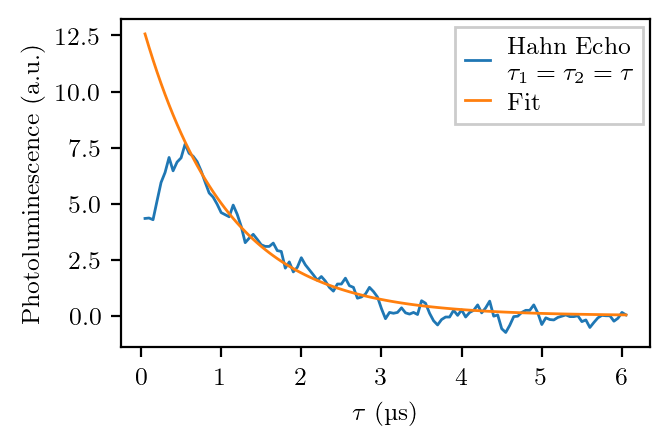

In [254]:
def exp_decay(t, A, gamma):
    return A * np.exp(-gamma * t)

hdecay_params, hdecay_pcov = curve_fit(exp_decay, decay[10:,0], decay[10:,1], p0=(8, 1))

fig5, ax = plt.subplots()
ax.plot(decay[:,0], decay[:,1], label="Hahn Echo\n"+r"$\tau_1=\tau_2=\tau$")
ax.plot(decay[:,0], exp_decay(decay[:,0], *hdecay_params), label="Fit")
ax.set(xlabel=r"$\tau$ (\unit{\micro\s)}", ylabel="Photoluminescence (a.u.)")
ax.legend()

# fig5.savefig("./figs/hahn_decay.pdf")

In [32]:
print(f"T2* = ({1/hdecay_params[1]:.2f} +- {hdecay_pcov[1,1]**0.5/hdecay_params[1]**2:.2f}) micro s")

T2* = (1.03 +- 0.03) micro s


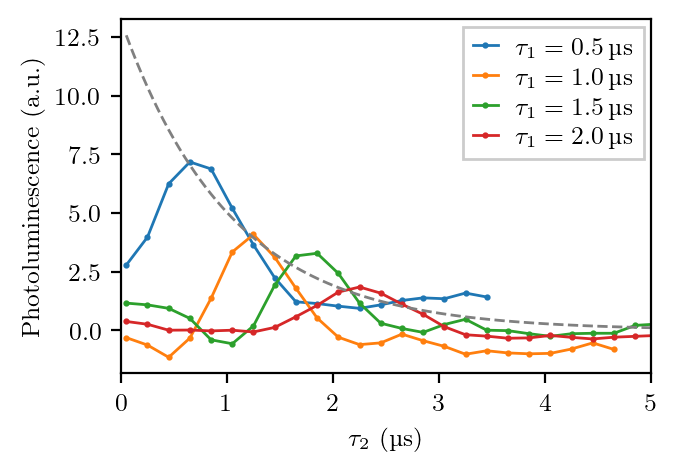

In [77]:
fig6, ax = plt.subplots()
ax.plot(echo_500[:,0], echo_500[:,1], label=r"$\tau_1=\qty{0.5}{\micro\s}$", marker=".")
ax.plot(echo_1000[:,0], echo_1000[:,1], label=r"$\tau_1=\qty{1.0}{\micro\s}$", marker=".")
ax.plot(echo_1500[:,0], echo_1500[:,1], label=r"$\tau_1=\qty{1.5}{\micro\s}$", marker=".")
ax.plot(echo_2000[:,0], echo_2000[:,1], label=r"$\tau_1=\qty{2.0}{\micro\s}$", marker=".")

# ax.plot(decay[:,0], decay[:,1], c="black")
ax.plot(decay[:,0], exp_decay(decay[:,0], *hdecay_params), c="gray", linestyle="--")

ax.set(xlabel=r"$\tau_2$ (\unit{\micro\s})", ylabel="Photoluminescence (a.u.)",
       xlim=(0, 5), )
ax.legend()

array([0.50743873, 1.0740319 , 1.59912118, 2.05469667])

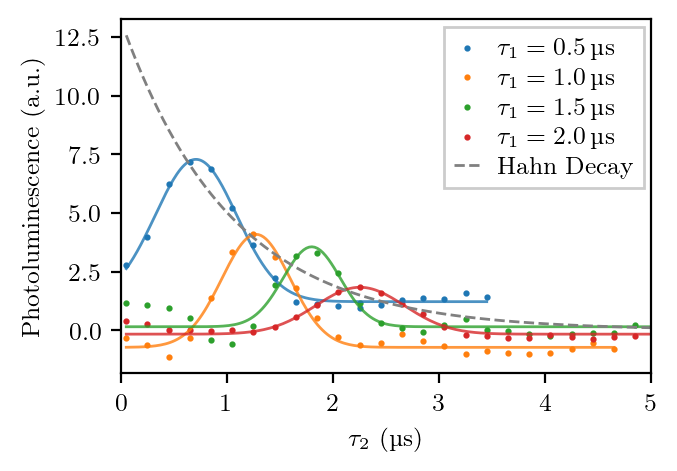

In [73]:
def gauss(x, A, B, x0, s):
    return A * np.exp(-(x-x0)**2 / (2*s**2)) + B

tau1s = np.arange(0.5, 2.5, 0.5)
tau2s = np.zeros(4)

fig7, ax = plt.subplots()
for i, data in enumerate(echo_list):
    params, pcov = curve_fit(gauss, data[:,0], data[:,1], p0=(3, 0, 1.5, 1))
    tau2s[i] = params[2]
    ax.scatter(data[:,0], data[:,1], marker=".", label=r"$\tau_1="+r"\qty{"+str(tau1s[i])+r"}{\micro\s}$")
    ts = np.linspace(data[0,0], data[-1,0], 200)
    ax.plot(ts, gauss(ts, *params), alpha=.8)

ax.plot(decay[:,0], exp_decay(decay[:,0], *hdecay_params), c="gray", linestyle="--", label="Hahn Decay")
ax.set(xlabel=r"$\tau_2$ (\unit{\micro\s})", ylabel="Photoluminescence (a.u.)", xlim=(0,5))
ax.legend()

tau2s - 0.200

array([ 0.96544818, -0.20668957])

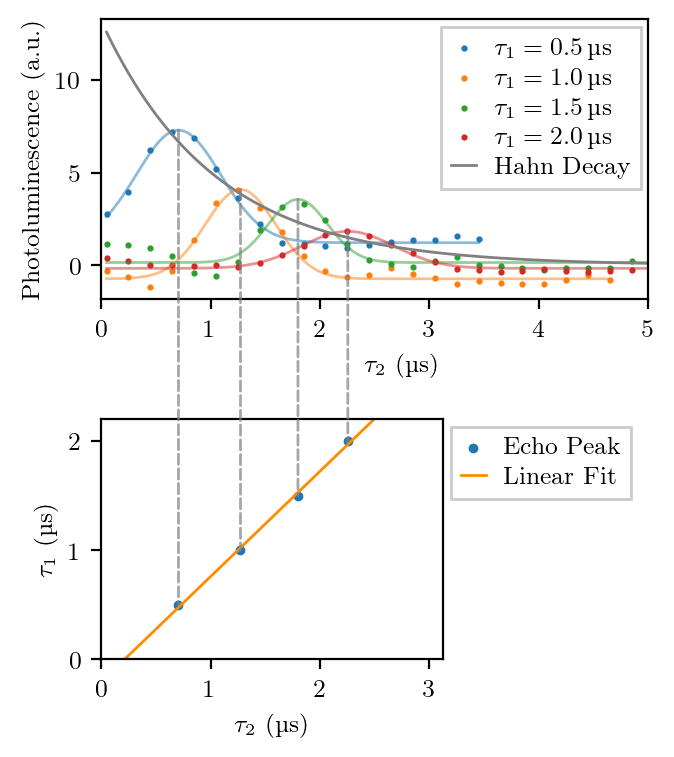

In [251]:
from matplotlib.patches import ConnectionPatch

def gauss(x, A, B, x0, s):
    return A * np.exp(-(x-x0)**2 / (2*s**2)) + B

tau1s = np.arange(0.5, 2.5, 0.5)
tau2s = np.zeros(4)
tau2s_err = np.zeros(4)
echo_peaks = np.zeros(4)


fig8 = plt.figure(figsize=(3.42, 4))
ax1 = fig8.add_axes([0.15, 0.55, 0.8, 0.35])
ax2 = fig8.add_axes([0.15, 0.1, 0.5, 0.3])

for i, data in enumerate(echo_list):
    params, pcov = curve_fit(gauss, data[:,0], data[:,1], p0=(3, 0, 1.5, 1))
    tau2s[i] = params[2]
    tau2s_err[i] = pcov[2,2]**0.5
    echo_peaks[i] = params[0] + params[1]
    ax1.scatter(data[:,0], data[:,1], marker=".", label=r"$\tau_1="+r"\qty{"+str(tau1s[i])+r"}{\micro\s}$")
    ts = np.linspace(data[0,0], data[-1,0], 200)
    ax1.plot(ts, gauss(ts, *params), alpha=.5)

ax1.plot(decay[:,0], exp_decay(decay[:,0], *hdecay_params), c="gray", linestyle="-", label="Hahn Decay")
ax1.set(xlabel=r"$\tau_2$ (\unit{\micro\s})", ylabel="Photoluminescence (a.u.)", xlim=(0,5))
xlabel_obj = ax1.set_xlabel(r"$\tau_2$ (\unit{\micro\s})")
current_x, current_y = xlabel_obj.get_position()
xlabel_obj.set_position((current_x + 0.05, current_y))
ax1.legend()

for i in range(4):
    con = ConnectionPatch(xyA=(tau2s[i], echo_peaks[i]), coordsA=ax1.transData,
                        xyB=(tau2s[i], tau1s[i]), coordsB=ax2.transData, color="gray", linestyle="--", alpha=.7)
    fig8.add_artist(con)

def linear(x, a, b):
    return a*x + b

params, pcov = curve_fit(linear, tau2s, tau1s)

ax2.scatter(tau2s, tau1s, label="Echo Peak")
ax2.plot(np.linspace(0, 2.5, 10), linear(np.linspace(0, 2.5, 10), *params), c="darkorange", label="Linear Fit")
ax2.set(xlabel=r"$\tau_2$ (\unit{\micro\s})", ylabel=r"$\tau_1$ (\unit{\micro\s})", ylim=(0,2.2),
        xlim=(0, 0.5/0.8 * 5))
ax2.legend(bbox_to_anchor=(1,1))

# fig8.savefig("./figs/hahn_echo.pdf")
params